In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import os
import dask
import dask.array

import datetime

from collections import Counter

import pystac_client
from pystac.extensions.projection import ProjectionExtension as proj

import planetary_computer
import rasterio
import rasterio.features
from rasterio.features import rasterize

import stackstac
import pyproj

import dask.diagnostics

from shapely.geometry import box
from shapely.ops import transform

from scipy.ndimage import binary_propagation
from scipy.ndimage import label



In [9]:
## OPEN PREVIOUSLY-CREATED ARRAY FROM DISK

stack_name = "tiles_wk"
ds = xr.open_zarr(f"/home/jupyter/{stack_name}.zarr", chunks="auto")
tiles_reload = ds[f'{stack_name}']
tiles_reload

<xarray.DataArray 'tiles_wk' (time: 22, band: 5, y: 2048, x: 2048)> Size: 4GB
dask.array<open_dataset-tiles_wk, shape=(22, 5, 2048, 2048), dtype=float64, chunksize=(3, 1, 256, 512), chunktype=numpy.ndarray>
Coordinates: (12/19)
  * band                                     (band) <U3 60B 'B04' ... 'B11'
    center_wavelength                        (band) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    common_name                              (band) <U6 120B dask.array<chunksize=(5,), meta=np.ndarray>
    constellation                            <U10 40B ...
    epsg                                     int64 8B ...
    full_width_half_max                      (band) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    ...                                       ...
    s2:product_type                          <U7 28B ...
    s2:saturated_defective_pixel_percentage  float64 8B ...
  * time                                     (time) datetime64[ns] 176B 2019-...
    title                                    (band) <U26 520B dask.array<chunksize=(5,), meta=np.ndarray>
  * x                                        (x) float64 16kB 5.507e+05 ... 5...
  * y                                        (y) float64 16kB 7.635e+06 ... 7...
Attributes:
    crs:         epsg:32622
    resolution:  10
    transform:   [10.0, 0.0, 549970.0, 0.0, -10.0, 7635420.0, 0.0, 0.0, 1.0]

In [50]:
# COMPUTE BAND MATH FOR WATER (NDWI, MNDWI, BmG, BmR/BpR)

# WATER INDICES AND MASKS
NDWI = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B08")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B08"))
NDWI = NDWI.fillna(0.0)
mask_NDWI = xr.where(NDWI >= 0.1, 1.0, 0.0)

MNDWI = (tiles_reload.sel(band="B02") - tiles_reload.sel(band="B11"))/(tiles_reload.sel(band="B02") + tiles_reload.sel(band="B11"))
MNDWI = MNDWI.fillna(0.0)

BmG = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B03")) / 10000
BmG = BmG.fillna(0.0)

BmR_BpR = (tiles_reload.sel(band="B02")-tiles_reload.sel(band="B04")) / (tiles_reload.sel(band="B02")+tiles_reload.sel(band="B04"))
BmR_BpR = BmR_BpR.fillna(0.0)



In [51]:
## CREATE WATER-TRACKER GRID OF SUBTILES THAT AVERAGE THE 

# size of each subtile
BY=BX=16

# compute 
subtile_sums = (
    mask_NDWI
      .coarsen(y=BY, x=BX, boundary="trim")  # chop into subtiles of given size BY=BX
      .sum()                                  # sum within each subtile
)

print(f"subtile grids created with shape: {subtile_sums.shape}")


subtile grids created with shape: (22, 128, 128)


In [52]:
## MASKS WATER MOVEMENT PIXELS TO HAVE ID OF LAKE

tiles = subtile_sums
da0   = tiles.isel(time=0)

# Read your vector and pick the subset you care about
gdf = gpd.read_file("/home/jupyter/dunmire_cw2019_shuttle.geojson")
gdf = gdf.to_crs(tiles_reload.rio.crs)  # make sure it’s in the same CRS

# Create a numeric code for each lake
#   You can either use a simple 1…N index…
gdf["lake_id"] = np.arange(1, len(gdf) + 1)

# …or map your string “lakenum” to an integer if you want:
# unique_vals = gdf["lakenum"].unique()
# id_map = {val: i+1 for i, val in enumerate(unique_vals)}
# gdf["lake_id"] = gdf["lakenum"].map(id_map)

# Build the shapes iterator: (geometry, lake_id)
shapes = ((geom, lid) for geom, lid in zip(gdf.geometry, gdf.lake_id))

# Rasterize into an integer mask
mask_arr = rasterize(
    shapes,
    out_shape=da0.rio.shape,
    transform=da0.rio.transform(),
    fill=0,        # 0 = “no lake”
    dtype="uint16" # or larger if you have >65535 lakes
)

# Wrap back into an xarray
lake_id_mask = xr.DataArray(
    mask_arr,
    dims=("y", "x"),
    coords={"y": da0.y, "x": da0.x},
    name="lake_id_mask",
)
# (Optional) broadcast if you need the time dims:
full_mask = lake_id_mask\
    .expand_dims(time=tiles.time)\
    .transpose("time","y","x")

# If you want to remember which integer maps to which lakenum:
lake_id_mask.attrs["id_to_lakenum"] = dict(zip(gdf.lake_id, gdf.lakenum))

# print(lake_id_mask)
# print("Legend:", lake_id_mask.attrs["id_to_lakenum"])
print(f"full_mask.shape: {full_mask.shape}")


full_mask.shape: (22, 128, 128)


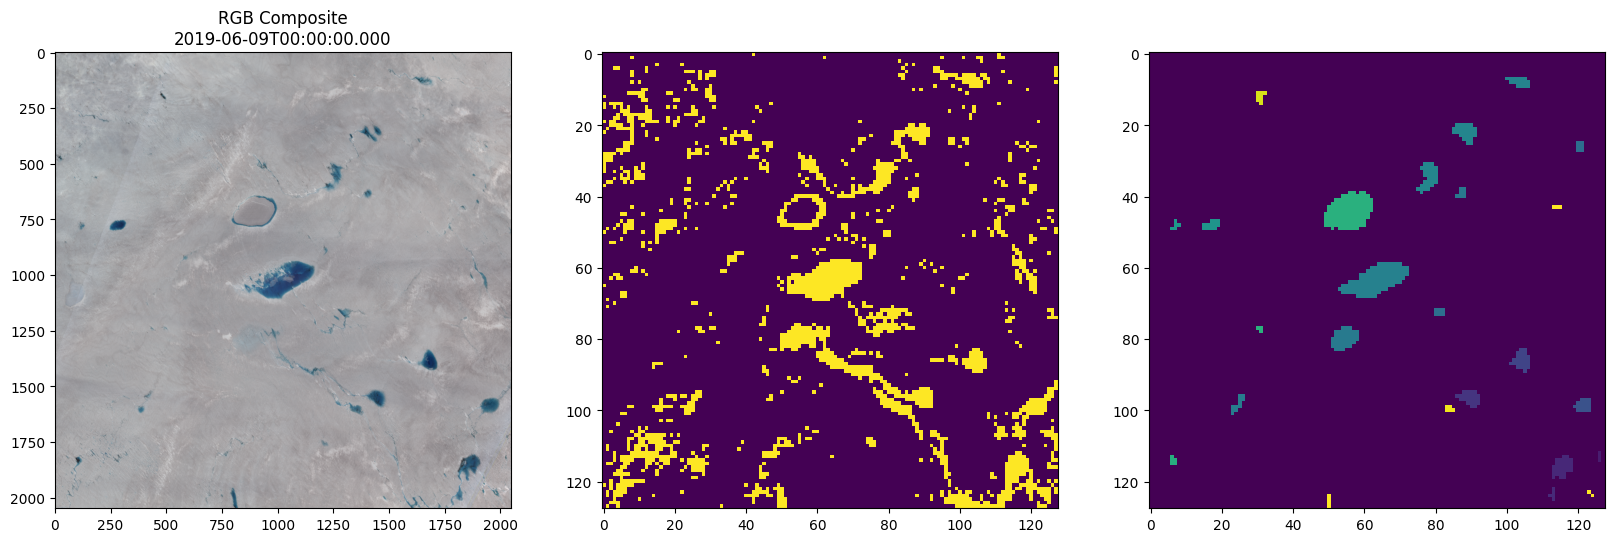

In [57]:


idx_date = 5

plt.figure(figsize=(20,20))
plt.subplot(1,3,1)
img3 = tiles_reload.isel(time=idx_date, band=[0,1,2]).values   # shape (3, H, W)
rgb = np.moveaxis(img3, 0, -1)
plt.imshow(rgb)
plt.title(f"RGB Composite\n{tiles_reload.isel(time=idx_date, band=[0,1,2]).time.values.astype('datetime64[ms]')}")

plt.subplot(1,3,2)
pathway_threshold = 0
B = subtile_sums.values[idx_date,] > pathway_threshold
B_dilated = binary_dilation(B, structure=kernel, iterations=1)
plt.imshow(B)
# plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(full_mask[idx_date,])
plt.clim(300, 450)

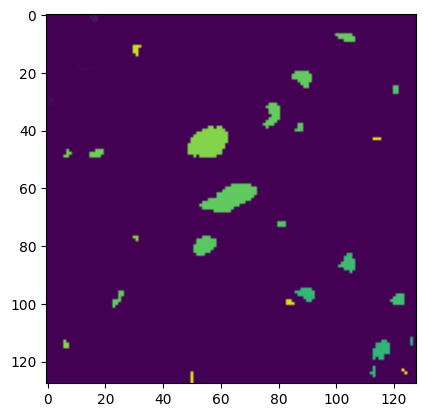

In [54]:



lbl = full_mask[0,]
plt.imshow(lbl)



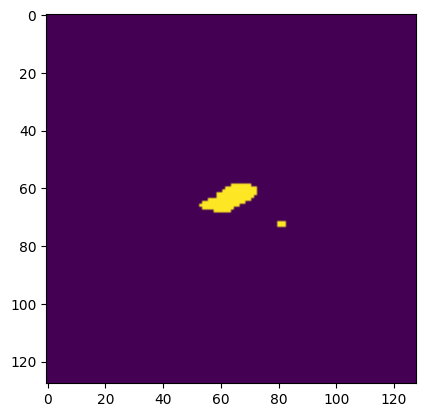

In [55]:
lake1 = 366
lake2 = 355

twolakes = (lbl == lake1) | (lbl == lake2)

plt.imshow(twolakes)



In [59]:

idx_date = 4
pathway_threshold = 0

A = twolakes
B = subtile_sums.values[idx_date,]>pathway_threshold

# 1) label the two islands in A
islands, n_islands = label(A, structure=np.ones((3,3),bool))
if n_islands != 2:
    raise ValueError(f"Expected exactly 2 islands in A, got {n_islands}")

# mask for island1
seed = (islands == 1)

# allow flooding on both walkway B and island2 itself
flood_mask = (B==1) | (islands == 2)

# flood from seed, using 8-connectivity
reach = binary_propagation(seed, structure=np.ones((3,3),bool), mask=flood_mask)

# if any pixel of island2 is reached, they’re connected
connected = np.any( reach & (islands == 2) )
print("Connected?", connected)




Connected? True
